# 02 — House-price modeling with a log-price target

This is the project's single modeling notebook. All candidate models are fitted to `log1p(SalePrice)`, selected using validation metrics on the log-price scale, and evaluated once on the held-out test set after selection.

## Modeling protocol

- Fixed shuffled split: 1,800 training, 600 validation, and 508 test observations.
- The 47-feature contract is identical to the EDA notebook.
- Numeric predictors and the ordinal basement-quality variable are standardized within each fit. Neighborhood indicators remain 0/1.
- `log1p(SalePrice)` is standardized internally during fitting, then returned to the log-price scale before all reported metrics are calculated. Thus MSE, RMSE, and MAE are not arbitrary standardized-unit scores.
- Candidate models are selected exclusively by validation MSE. Test metrics are calculated only for the selected model, never used for selection.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')

DATA_FILENAME = 'IA_House_Price_Original_Data.xlsx'
DATA_CANDIDATES = [Path('../data') / DATA_FILENAME, Path('data') / DATA_FILENAME]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f'Could not find {DATA_FILENAME} in the repository data directory.')
TARGET = 'SalePrice'
RANDOM_SEED = 20260928

numeric_features = [
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'FullBath',
    'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
]
neighbourhoods = [
    'Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards',
    'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NPkVill', 'NWAmes', 'NoRidge',
    'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker',
]
bsmtqual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}


/Users/kerolin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
raw = pd.read_excel(DATA_PATH, skiprows=3)
raw.columns = raw.columns.astype(str).str.strip()
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')].copy()

clean = raw.copy()
clean['BsmtFinSF'] = clean['BsmtFinSF1'] + clean['BsmtFinSF2']
clean['BsmtQual_ordinal'] = clean['BsmtQual'].fillna('NA').map(bsmtqual_map)

if set(clean['Neighborhood'].dropna()) != set(neighbourhoods):
    raise ValueError('Neighborhood categories do not match the 25-feature specification.')
neighbourhood_columns = [f'NBHD_{name}' for name in neighbourhoods]
dummies = pd.get_dummies(clean['Neighborhood'], prefix='NBHD', dtype=int).reindex(
    columns=neighbourhood_columns, fill_value=0
)
X_47 = pd.concat([clean[numeric_features], clean[['BsmtQual_ordinal']], dummies], axis=1)
y_price = clean[TARGET].copy()

assert X_47.shape[1] == 47, f'Expected 47 features, found {X_47.shape[1]}.'
assert not X_47.isna().any().any(), 'Selected regressors contain missing values.'
assert not y_price.isna().any(), 'SalePrice contains missing values.'

display(pd.Series({
    'observations': len(X_47), 'features': X_47.shape[1],
    'missing_regressor_values': int(X_47.isna().sum().sum()),
    'missing_target_values': int(y_price.isna().sum()),
}).to_frame('value'))


,value
observations,2908
features,47
missing_regressor_values,0
missing_target_values,0


## Complete list of 47 features

The intercept is separate and is not counted as a feature.

In [3]:
feature_list = pd.DataFrame({
    'No.': np.arange(1, 48), 'Feature': X_47.columns,
    'Type': ['Numerical'] * 21 + ['Ordinal'] + ['Neighborhood indicator'] * 25,
})
with pd.option_context('display.max_rows', None):
    display(feature_list.set_index('No.'))


,Feature,Type
No.,,
1,LotArea,Numerical
2,OverallQual,Numerical
3,OverallCond,Numerical
4,YearBuilt,Numerical
5,YearRemodAdd,Numerical
6,BsmtFinSF,Numerical
7,BsmtUnfSF,Numerical
8,TotalBsmtSF,Numerical
9,1stFlrSF,Numerical


In [4]:
rng = np.random.default_rng(RANDOM_SEED)
permutation = rng.permutation(len(X_47))
train_idx, validation_idx, test_idx = permutation[:1800], permutation[1800:2400], permutation[2400:]

X_train, y_train = X_47.iloc[train_idx], y_price.iloc[train_idx]
X_validation, y_validation = X_47.iloc[validation_idx], y_price.iloc[validation_idx]
X_test, y_test = X_47.iloc[test_idx], y_price.iloc[test_idx]
assert (len(X_train), len(X_validation), len(X_test)) == (1800, 600, 508)

display(pd.DataFrame({
    'observations': [len(X_train), len(X_validation), len(X_test)],
    'mean_saleprice': [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=['train', 'validation', 'test']).round(2))


,observations,mean_saleprice
train,1800,180018.88
validation,600,178133.52
test,508,183695.88


## Models and metrics

OLS, Ridge, and Lasso are fitted with the assignment's specified penalty strengths. The primary metrics below evaluate `log1p(SalePrice)`: MSE, RMSE, MAE, and R². The raw-dollar target is never used as the fitting baseline.

In [5]:
scaled_features = numeric_features + ['BsmtQual_ordinal']

def make_regressor_pipeline(estimator):
    preprocessing = ColumnTransformer(
        [('scaled', StandardScaler(), scaled_features),
         ('neighborhood', 'passthrough', neighbourhood_columns)],
        verbose_feature_names_out=False,
    )
    return Pipeline([('preprocess', preprocessing), ('model', estimator)])

def make_log_target_model(estimator):
    # Pipeline inversion is StandardScaler inverse followed by expm1.
    target_transformer = Pipeline([
        ('log', FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=False)),
        ('scale', StandardScaler()),
    ])
    return TransformedTargetRegressor(
        regressor=make_regressor_pipeline(estimator),
        transformer=target_transformer,
    )

def log_scale_metrics(actual_price, predicted_price):
    actual_log = np.log1p(actual_price)
    predicted_log = np.log1p(np.maximum(predicted_price, 0))
    return {
        'mse': mean_squared_error(actual_log, predicted_log),
        'rmse': np.sqrt(mean_squared_error(actual_log, predicted_log)),
        'mae': mean_absolute_error(actual_log, predicted_log),
        'r2': r2_score(actual_log, predicted_log),
    }

candidates = {
    'OLS': LinearRegression(),
    **{f'Ridge (alpha={alpha:.2f})': Ridge(alpha=alpha) for alpha in [0.10, 0.30, 0.60]},
    **{f'Lasso (alpha={alpha:.2f})': Lasso(alpha=alpha, max_iter=50_000) for alpha in [0.02, 0.06, 0.10]},
}

fitted_candidates, records = {}, []
for name, estimator in candidates.items():
    model = make_log_target_model(estimator)
    model.fit(X_train, y_train)
    fitted_candidates[name] = model
    train_metrics = log_scale_metrics(y_train, model.predict(X_train))
    validation_metrics = log_scale_metrics(y_validation, model.predict(X_validation))
    records.append({
        'model': name,
        **{f'train_{metric}': value for metric, value in train_metrics.items()},
        **{f'validation_{metric}': value for metric, value in validation_metrics.items()},
    })

model_metrics = pd.DataFrame(records).sort_values('validation_mse').reset_index(drop=True)
best_validation_mse = model_metrics.loc[0, 'validation_mse']
model_metrics['validation_mse_delta_to_best'] = model_metrics['validation_mse'] - best_validation_mse
model_metrics['validation_mse_pct_above_best'] = 100 * model_metrics['validation_mse_delta_to_best'] / best_validation_mse
display(model_metrics.round(8))


,model,train_mse,train_rmse,train_mae,train_r2,validation_mse,validation_rmse,validation_mae,validation_r2,validation_mse_delta_to_best,validation_mse_pct_above_best
0,OLS,0.013908,0.117930,0.080995,0.912059,0.014917,0.122137,0.084055,0.914905,0.000000,0.000000
1,Ridge (alpha=0.60),0.013904,0.117914,0.081020,0.912083,0.014929,0.122186,0.083999,0.914837,0.000012,0.080107
2,Ridge (alpha=0.30),0.013902,0.117908,0.081008,0.912092,0.014933,0.122201,0.084024,0.914816,0.000016,0.104815
3,Ridge (alpha=0.10),0.013902,0.117906,0.081004,0.912094,0.014936,0.122213,0.084046,0.914798,0.000019,0.125443
4,Lasso (alpha=0.02),0.016669,0.129110,0.091020,0.894595,0.017505,0.132305,0.092142,0.900147,0.002587,17.343160
5,Lasso (alpha=0.06),0.019338,0.139063,0.097379,0.877718,0.021760,0.147513,0.103026,0.875871,0.006843,45.870798
6,Lasso (alpha=0.10),0.022969,0.151554,0.107108,0.854762,0.026563,0.162982,0.114689,0.848473,0.011646,78.068131


## Complete parameters of all seven candidates

The table contains the intercept and all 47 slopes for each 1,800-observation training fit. Predictor and target standardization are reversed: coefficients use **original input units** and the **log1p(SalePrice) target scale**. These units differ from the standardized-predictor coefficient plots below.

OLS coefficients represent one numerical solution, not uniquely identified: neighborhood indicators sum to one, and finished plus unfinished basement area equals total basement area.

In [6]:
def original_input_log_parameters(fitted_model, check_X):
    """Undo predictor and target scaling; retain the log1p price target."""
    reg = fitted_model.regressor_
    pre = reg.named_steps['preprocess']
    est = reg.named_steps['model']
    names = list(pre.get_feature_names_out())
    sy = fitted_model.transformer_.named_steps['scale']
    sx = pre.named_transformers_['scaled']
    mean_x = pd.Series(0.0, index=names)
    scale_x = pd.Series(1.0, index=names)
    mean_x.loc[scaled_features] = sx.mean_
    scale_x.loc[scaled_features] = sx.scale_
    slopes = pd.Series(est.coef_ * sy.scale_[0], index=names) / scale_x
    intercept = float(sy.mean_[0] + sy.scale_[0] * est.intercept_ - slopes.dot(mean_x))
    reconstructed = intercept + check_X[names].to_numpy(dtype=float) @ slopes.to_numpy()
    expected = sy.mean_[0] + sy.scale_[0] * reg.predict(check_X)
    # Collinear OLS fits can contain large cancelling coefficients. Account
    # for the magnitude of intermediate sums, not just the final prediction.
    raw_X = check_X[names].to_numpy(dtype=float)
    transformed_X = pre.transform(check_X)
    raw_magnitude = abs(intercept) + np.abs(raw_X) @ np.abs(slopes.to_numpy())
    fitted_magnitude = abs(sy.mean_[0]) + abs(sy.scale_[0]) * (
        abs(est.intercept_) + np.abs(transformed_X) @ np.abs(est.coef_)
    )
    conversion_magnitude = abs(sy.scale_[0] * est.intercept_) + float(
        np.abs(slopes.to_numpy()) @ np.abs(mean_x.to_numpy())
    )
    roundoff_bound = 64 * np.finfo(float).eps * (
        raw_magnitude + fitted_magnitude + conversion_magnitude
    )
    allowed_error = 1e-8 + 1e-8 * np.abs(expected) + roundoff_bound
    error = np.abs(reconstructed - expected)
    if not (np.isfinite(reconstructed).all() and np.isfinite(expected).all()):
        raise ValueError('Non-finite values found during parameter reconstruction.')
    if np.any(error > allowed_error):
        raise AssertionError(
            f'{type(est).__name__}: parameter reconstruction exceeds the numerical '
            f'error allowance (max error={error.max():.3g}).'
        )
    if error.max() > 1e-6:
        print(f'Note: {type(est).__name__} has cancelling coefficients; '
              f'parameter reconstruction differs by up to {error.max():.3g} '
              'log-price units. Use the fitted pipeline for predictions and '
              'do not interpret individual OLS coefficients as stable effects.')
    return pd.concat([pd.Series({'Intercept': intercept}), slopes])

candidate_parameter_table = pd.DataFrame({
    name: original_input_log_parameters(fitted_candidates[name], X_train)
    for name in candidates
})
candidate_parameter_table.index.name = 'Parameter'
assert candidate_parameter_table.shape == (48, 7)
print('Candidate models: 1,800 training observations.')
print('predicted log1p(SalePrice) = Intercept + sum(coefficient * original feature)')
print('Numerical inputs use original units; BsmtQual uses 0–5; neighborhood indicators use 0/1.')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.float_format', lambda v: f'{v:.10g}'):
    display(candidate_parameter_table)


Note: LinearRegression has cancelling coefficients; parameter reconstruction differs by up to 0.000114 log-price units. Use the fitted pipeline for predictions and do not interpret individual OLS coefficients as stable effects.
Candidate models: 1,800 training observations.
predicted log1p(SalePrice) = Intercept + sum(coefficient * original feature)
Numerical inputs use original units; BsmtQual uses 0–5; neighborhood indicators use 0/1.


,OLS,Ridge (alpha=0.10),Ridge (alpha=0.30),Ridge (alpha=0.60),Lasso (alpha=0.02),Lasso (alpha=0.06),Lasso (alpha=0.10)
Parameter,,,,,,,
Intercept,1187908551,3.413369764,3.402849611,3.387791696,3.425376715,5.010756053,6.380184107
LotArea,2.499664799e-06,2.504491008e-06,2.513885041e-06,2.527367052e-06,2.429910922e-06,1.083995779e-06,0
OverallQual,0.07251729937,0.0719481961,0.0720068499,0.07209240511,0.08687349372,0.09434269313,0.09864124711
OverallCond,0.05444095787,0.05485265197,0.05479477488,0.05471067465,0.03767502705,0.01057937888,0
YearBuilt,0.002798266905,0.00282078857,0.0028214603,0.002822321775,0.002415212556,0.001542193479,0.00109822654
YearRemodAdd,0.0007950229212,0.0007713852241,0.0007757630463,0.0007821215141,0.001182593928,0.001346622744,0.001148465073
BsmtFinSF,-214459505.8,8.163171179e-05,8.161915808e-05,8.160088933e-05,8.54963232e-05,7.558002712e-05,6.024608072e-05
BsmtUnfSF,-214459505.8,-6.847938812e-06,-6.83044782e-06,-6.805328154e-06,-0,-0,-0
TotalBsmtSF,214459505.8,8.895395603e-05,8.895821076e-05,8.896403798e-05,8.288758061e-05,8.010954019e-05,8.042773257e-05


## Final test evaluation

Only the candidate with the lowest validation MSE is refitted on training plus validation data. This prevents test-set metrics from influencing model selection.

,selected_model,target_for_metrics,test_mse,test_rmse,test_mae,test_r2
0,OLS,log1p(SalePrice),0.0144,0.1201,0.0862,0.9087


,test_rmse_usd,test_mae_usd
0,21545.45,14996.77


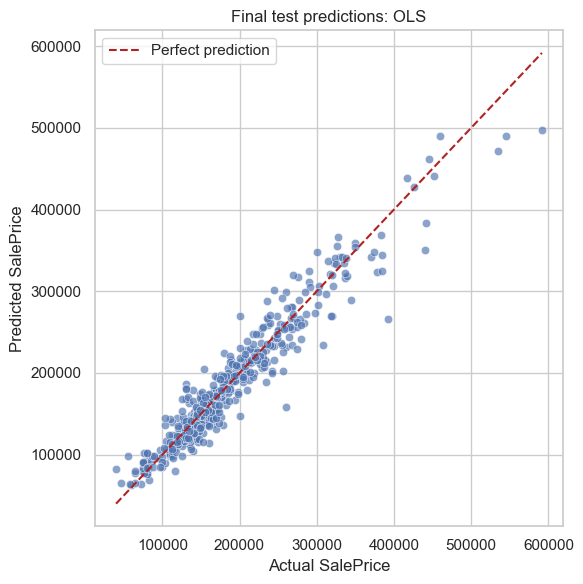

In [7]:
best_model_name = model_metrics.loc[0, 'model']
best_estimator = candidates[best_model_name]
X_development = pd.concat([X_train, X_validation])
y_development = pd.concat([y_train, y_validation])

final_model = make_log_target_model(best_estimator)
final_model.fit(X_development, y_development)
test_prediction = final_model.predict(X_test)
test_metrics = log_scale_metrics(y_test, test_prediction)

final_test_metrics = pd.DataFrame([{
    'selected_model': best_model_name,
    'target_for_metrics': 'log1p(SalePrice)',
    'test_mse': test_metrics['mse'],
    'test_rmse': test_metrics['rmse'],
    'test_mae': test_metrics['mae'],
    'test_r2': test_metrics['r2'],
}])
display(final_test_metrics.round(4))

dollar_metrics = pd.DataFrame([{
    'test_rmse_usd': np.sqrt(mean_squared_error(y_test, test_prediction)),
    'test_mae_usd': mean_absolute_error(y_test, test_prediction),
}])
display(dollar_metrics.round(2))

plot_data = pd.DataFrame({'actual_saleprice': y_test, 'predicted_saleprice': test_prediction})
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(data=plot_data, x='actual_saleprice', y='predicted_saleprice', alpha=0.65)
limits = [plot_data.min().min(), plot_data.max().max()]
ax.plot(limits, limits, '--', color='firebrick', label='Perfect prediction')
ax.set(title=f'Final test predictions: {best_model_name}', xlabel='Actual SalePrice', ylabel='Predicted SalePrice')
ax.legend()
plt.tight_layout()
plt.show()


Best model selected by validation MSE: OLS
Coefficients are in log-price units. Numerical feature coefficients correspond to standardized predictors.


,feature,log_price_coefficient,abs_coefficient
5,BsmtFinSF,-3.521116e+11,3.521116e+11
6,BsmtUnfSF,-3.382053e+11,3.382053e+11
7,TotalBsmtSF,3.239798e+11,3.239798e+11
32,NBHD_MeadowV,-1.209319e+10,1.209319e+10
24,NBHD_BrDale,-1.209319e+10,1.209319e+10
23,NBHD_Blueste,-1.209319e+10,1.209319e+10
35,NBHD_NPkVill,-1.209319e+10,1.209319e+10
31,NBHD_IDOTRR,-1.209319e+10,1.209319e+10
39,NBHD_OldTown,-1.209319e+10,1.209319e+10
36,NBHD_NWAmes,-1.209319e+10,1.209319e+10


,display_feature,log_price_coefficient
0,BsmtQual (ordinal),1.852880e-02
7,Crawfor,-1.209319e+10
23,StoneBr,-1.209319e+10
17,NridgHt,-1.209319e+10
22,Somerst,-1.209319e+10
5,ClearCr,-1.209319e+10
16,NoRidge,-1.209319e+10
24,Timber,-1.209319e+10
4,BrkSide,-1.209319e+10
9,Gilbert,-1.209319e+10


,feature,log_price_coefficient
7,TotalBsmtSF,3.239798e+11
10,GrLivArea,1.110710e-01
1,OverallQual,9.898155e-02
3,YearBuilt,8.692729e-02
2,OverallCond,6.192426e-02
17,GarageArea,2.337701e-02
16,GarageCars,2.134930e-02
15,Fireplaces,2.000200e-02
0,LotArea,1.901989e-02
4,YearRemodAdd,1.813341e-02


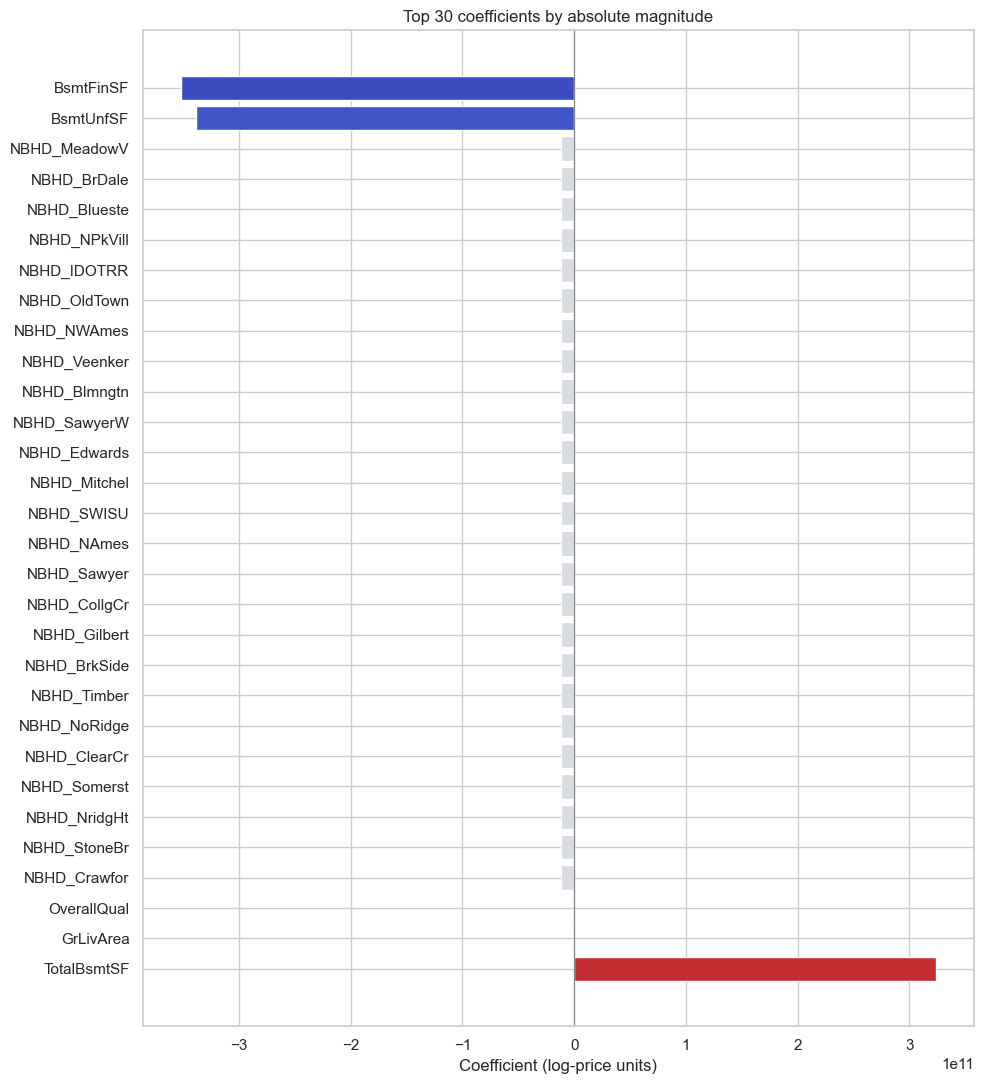

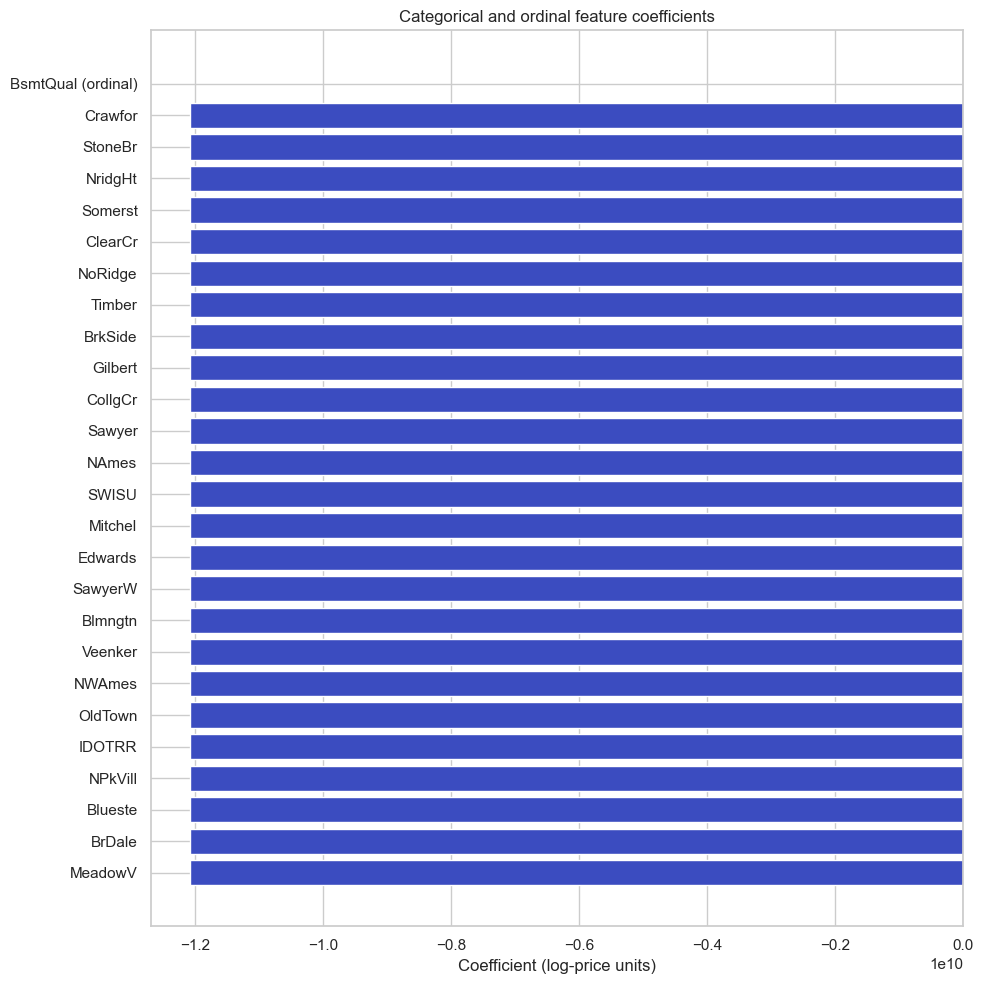

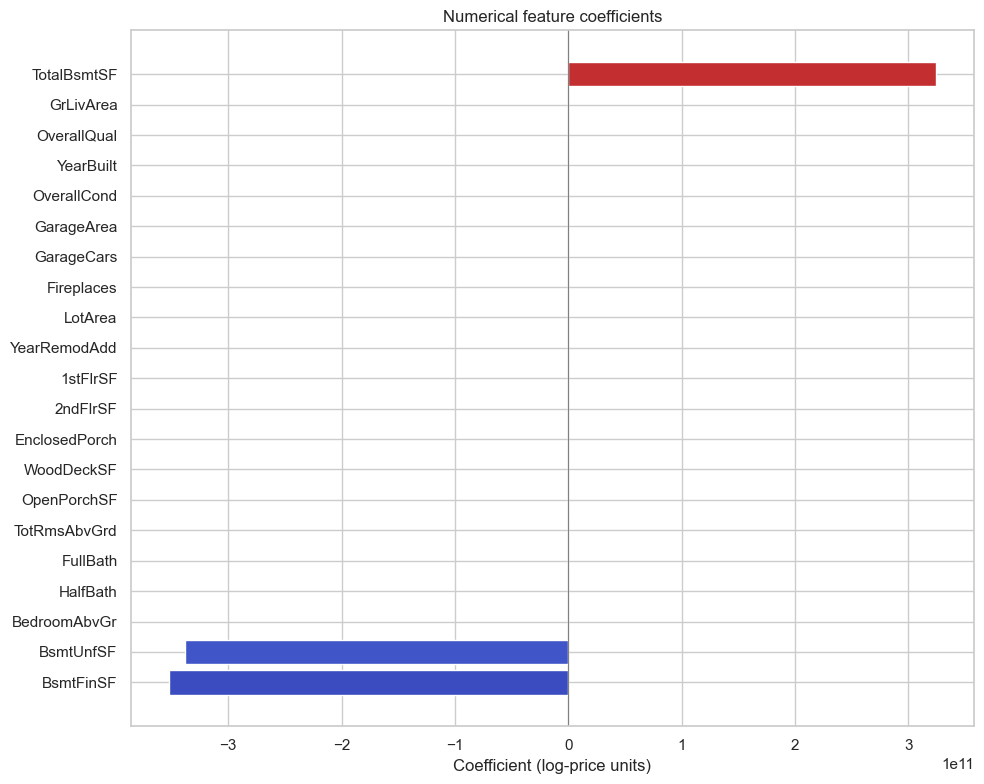

In [8]:
# Convert coefficients from standardized-target units back to log-price units.
target_log_std = final_model.transformer_.named_steps['scale'].scale_[0]
coefficient_table = pd.DataFrame({
    'feature': final_model.regressor_.named_steps['preprocess'].get_feature_names_out(),
    'log_price_coefficient': final_model.regressor_.named_steps['model'].coef_ * target_log_std,
})
coefficient_table['abs_coefficient'] = coefficient_table['log_price_coefficient'].abs()

# 1. Top 30 coefficients by absolute magnitude across all 47 features.
top_30_coefficients = coefficient_table.sort_values('abs_coefficient', ascending=False).head(30)

# 2. Categorical features: one ordinal basement-quality feature plus 25 neighborhood indicators.
categorical_features = ['BsmtQual_ordinal'] + neighbourhood_columns
categorical_coefficients = coefficient_table.set_index('feature').loc[categorical_features].reset_index()
categorical_coefficients['display_feature'] = categorical_coefficients['feature'].replace({'BsmtQual_ordinal': 'BsmtQual (ordinal)'})
categorical_coefficients['display_feature'] = categorical_coefficients['display_feature'].str.removeprefix('NBHD_')
categorical_coefficients = categorical_coefficients.sort_values('log_price_coefficient', ascending=False)

# 3. Numerical features: all 21 numeric features in the assignment contract.
numerical_coefficients = coefficient_table.set_index('feature').loc[numeric_features].reset_index()
numerical_coefficients = numerical_coefficients.sort_values('log_price_coefficient', ascending=False)

print(f'Best model selected by validation MSE: {best_model_name}')
print('Coefficients are in log-price units. Numerical feature coefficients correspond to standardized predictors.')
display(top_30_coefficients[['feature', 'log_price_coefficient', 'abs_coefficient']].round(8))
display(categorical_coefficients[['display_feature', 'log_price_coefficient']].round(8))
display(numerical_coefficients[['feature', 'log_price_coefficient']].round(8))

# Matplotlib bars avoid seaborn-version differences in the legend argument.
def plot_coefficient_bars(table, label_column, title, figsize):
    values = table['log_price_coefficient'].to_numpy()
    labels = table[label_column].astype(str).tolist()
    color_limit = max(float(np.abs(values).max()), 1e-12)
    cmap = plt.get_cmap('coolwarm')
    colors = cmap((values / color_limit + 1.0) / 2.0)
    fig, axis = plt.subplots(figsize=figsize)
    positions = np.arange(len(table))
    axis.barh(positions, values, color=colors)
    axis.set_yticks(positions)
    axis.set_yticklabels(labels)
    axis.invert_yaxis()
    axis.axvline(0, color='gray', linewidth=0.8)
    axis.set(title=title, xlabel='Coefficient (log-price units)', ylabel='')
    plt.tight_layout()
    plt.show()

plot_coefficient_bars(
    top_30_coefficients.sort_values('log_price_coefficient'), 'feature',
    'Top 30 coefficients by absolute magnitude', (10, 11))
plot_coefficient_bars(
    categorical_coefficients, 'display_feature',
    'Categorical and ordinal feature coefficients', (10, 10))
plot_coefficient_bars(
    numerical_coefficients, 'feature',
    'Numerical feature coefficients', (10, 8))


## Interpretation guardrails

The reported primary metrics are on the log-price scale, so they measure proportional pricing error more naturally than dollar-scale errors. Dollar RMSE and MAE are supplied only as an intuitive supplement for the final selected model. Coefficients are conditional prediction associations, not causal effects. Retaining all 25 neighborhood dummies honors the 47-feature contract; with an intercept, OLS dummy coefficients are not individually identified even though its predictions are well-defined.

## Complete parameters of the final refitted model

This table uses the same units as the candidate table, but reflects the final fit on 2,400 observations.

In [9]:
final_parameter_table = original_input_log_parameters(final_model, X_development).to_frame(
    name=f'Final {best_model_name}')
final_parameter_table.index.name = 'Parameter'
print('Final model: refitted on 2,400 training + validation observations.')
print('The equation and units match the candidate parameter table above.')
with pd.option_context('display.max_rows', None, 'display.float_format', lambda v: f'{v:.10g}'):
    display(final_parameter_table)


Note: LinearRegression has cancelling coefficients; parameter reconstruction differs by up to 0.000384 log-price units. Use the fitted pipeline for predictions and do not interpret individual OLS coefficients as stable effects.
Final model: refitted on 2,400 training + validation observations.
The equation and units match the candidate parameter table above.


,Final OLS
Parameter,
Intercept,1.209319275e+10
LotArea,2.39631659e-06
OverallQual,0.07085582747
OverallCond,0.05565092549
YearBuilt,0.002859252048
YearRemodAdd,0.0008639002408
BsmtFinSF,-767725470.6
BsmtUnfSF,-767725470.6
TotalBsmtSF,767725470.6


## Model Prediction

This section applies the existing final model to 4015 Marigold Dr, Ames, IA 50014, an external single-family property in the Edwards neighborhood. The row is not added to the training, validation, or test partitions and does not affect model selection. The audit table reports every input and its source; values labelled Estimated from Zillow listing are baseline assumptions rather than verified property facts.

In [10]:
external_property_values = {
    'LotArea': 7405.2, 'OverallQual': 7, 'OverallCond': 6, 'YearBuilt': 2002,
    'YearRemodAdd': 2024, 'BsmtFinSF': 1286, 'BsmtUnfSF': 0, 'TotalBsmtSF': 1286,
    '1stFlrSF': 1000, '2ndFlrSF': 351, 'GrLivArea': 1351, 'FullBath': 2,
    'HalfBath': 0, 'BedroomAbvGr': 4, 'TotRmsAbvGrd': 7, 'Fireplaces': 1,
    'GarageCars': 2, 'GarageArea': 424, 'WoodDeckSF': 173, 'OpenPorchSF': 0,
    'EnclosedPorch': 0, 'BsmtQual_ordinal': 4,
}
provided_sources = {
    'LotArea': 'Zillow Listing', 'YearBuilt': 'Zillow Listing',
    'BsmtFinSF': 'Zillow Listing', 'BsmtUnfSF': 'Zillow Listing',
    'TotalBsmtSF': 'Zillow Listing', 'GrLivArea': 'Zillow Listing',
    'FullBath': 'Zillow Listing', 'HalfBath': 'Zillow Listing',
    'BedroomAbvGr': 'Zillow Listing', 'Fireplaces': 'Zillow Listing',
    'GarageCars': 'Zillow Listing',
}
estimated_source = 'Estimated from Zillow listing'
external_property_values.update({f'NBHD_{name}': int(name == 'Edwards') for name in neighbourhoods})
external_property_sources = {feature: provided_sources.get(feature, estimated_source) for feature in X_47.columns}
external_property_sources.update({f'NBHD_{name}': 'Zillow Listing' for name in neighbourhoods})
external_property = pd.DataFrame([external_property_values], columns=X_47.columns)
assert external_property.shape == (1, 47)
assert external_property.columns.equals(X_47.columns)
assert not external_property.isna().any().any()
assert external_property.at[0, 'NBHD_Edwards'] == 1
assert external_property.filter(like='NBHD_').sum(axis=1).eq(1).all()
external_property_audit = pd.DataFrame({'Data': external_property.iloc[0], 'Source': pd.Series(external_property_sources)}).loc[X_47.columns]
external_property_audit.index.name = 'Feature'
print(external_property_audit.to_string())

external_prediction_usd = float(final_model.predict(external_property)[0])
model_prediction = pd.DataFrame([{
    'property': '4015 Marigold Dr, Ames, IA 50014',
    'neighborhood': 'Edwards', 'selected_model': best_model_name,
    'predicted_saleprice_usd': external_prediction_usd,
    'predicted_log1p_saleprice': np.log1p(max(external_prediction_usd, 0)),
}])
print(model_prediction.round({'predicted_saleprice_usd': 2, 'predicted_log1p_saleprice': 8}).to_string(index=False))


                    Data                         Source
Feature                                                
LotArea           7405.2                 Zillow Listing
OverallQual          7.0  Estimated from Zillow listing
OverallCond          6.0  Estimated from Zillow listing
YearBuilt         2002.0                 Zillow Listing
YearRemodAdd      2024.0  Estimated from Zillow listing
BsmtFinSF         1286.0                 Zillow Listing
BsmtUnfSF            0.0                 Zillow Listing
TotalBsmtSF       1286.0                 Zillow Listing
1stFlrSF          1000.0  Estimated from Zillow listing
2ndFlrSF           351.0  Estimated from Zillow listing
GrLivArea         1351.0                 Zillow Listing
FullBath             2.0                 Zillow Listing
HalfBath             0.0                 Zillow Listing
BedroomAbvGr         4.0                 Zillow Listing
TotRmsAbvGrd         7.0  Estimated from Zillow listing
Fireplaces           1.0                 Zillow 